# Laboratorium 10
**Autor:** [Jonasz Zolisz]

# Ćwiczenie 1 

In [1]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)


Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


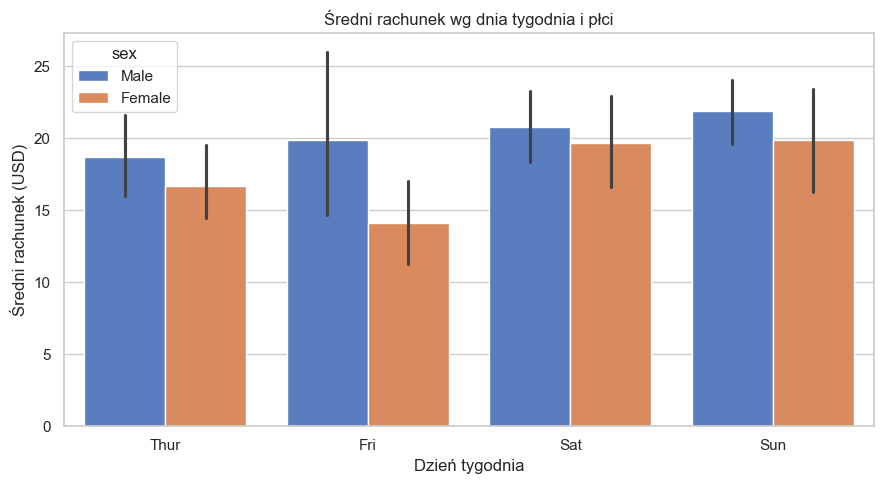

Zapisano: barplot_dzien_plec.png


In [2]:
# Ćw 1.1  Barplot z hue (wzór do skopiowania)
#Średni rachunek per dzień tygodnia, z podziałem wg płci.

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
 data=tips,
 x='day',
 y='total_bill',
 hue='sex',
 ax=ax,
 palette='muted',
 errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")


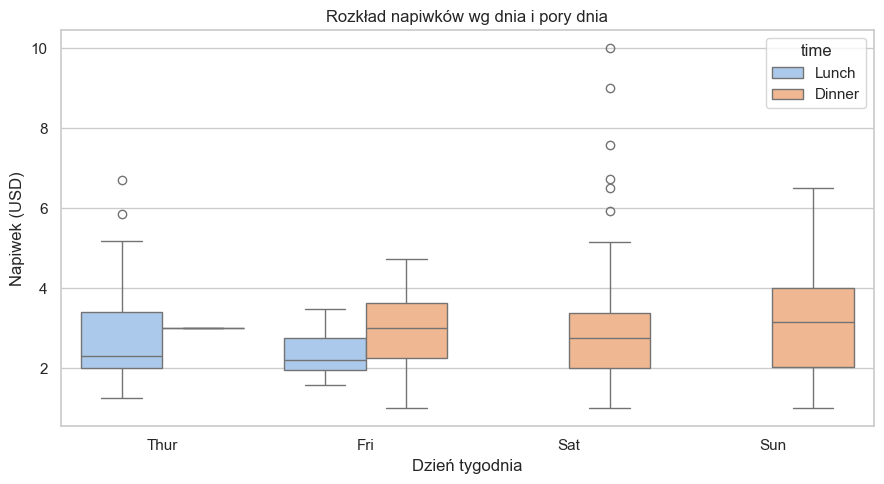

Zapisano: boxplot_napiwki.png


In [3]:
# Ćw 1.2 Boxplot (uzupełnij ???) Rozkład napiwków per dzień, z podziałem na Lunch/Dinner.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
 data=tips,
 x='day', # kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
 y='tip', # kolumna numeryczna na oś Y (napiwek)
 hue='time', # podział kolorystyczny (Lunch/Dinner)
 ax=ax,
 palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

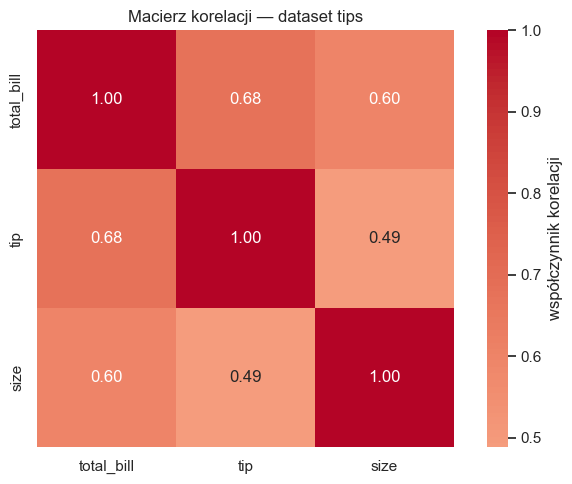

Zapisano: heatmap_korelacja.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
 corr,
 annot=True, # True — pokaż liczby w komórkach
 fmt='.2f', # 2 miejsca po przecinku
 cmap='coolwarm', # 'coolwarm' — paleta dywergencyjna (czerwony=+, niebieski=-)
 center=0, # 0 — środek skali (biały = 0 korelacja)
 ax=ax,
 square=True,
 cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

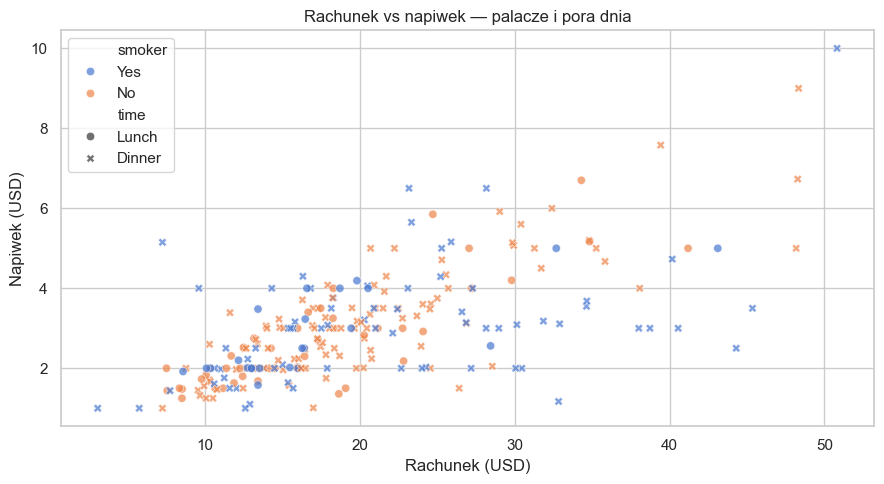

In [20]:
# 1.4  Scatter z hue + style (samodzielnie) Stwórz sns.scatterplot zależności rachunek↔napiwek, w którym
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    style='time',
    alpha=0.7,
    ax=ax,
)

ax.set_title('Rachunek vs napiwek — palacze i pora dnia')
ax.set_xlabel('Rachunek (USD)')
ax.set_ylabel('Napiwek (USD)')

plt.tight_layout()

plt.savefig(
    'scatter_rachunek_napiwek.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()


# Ćw 2 

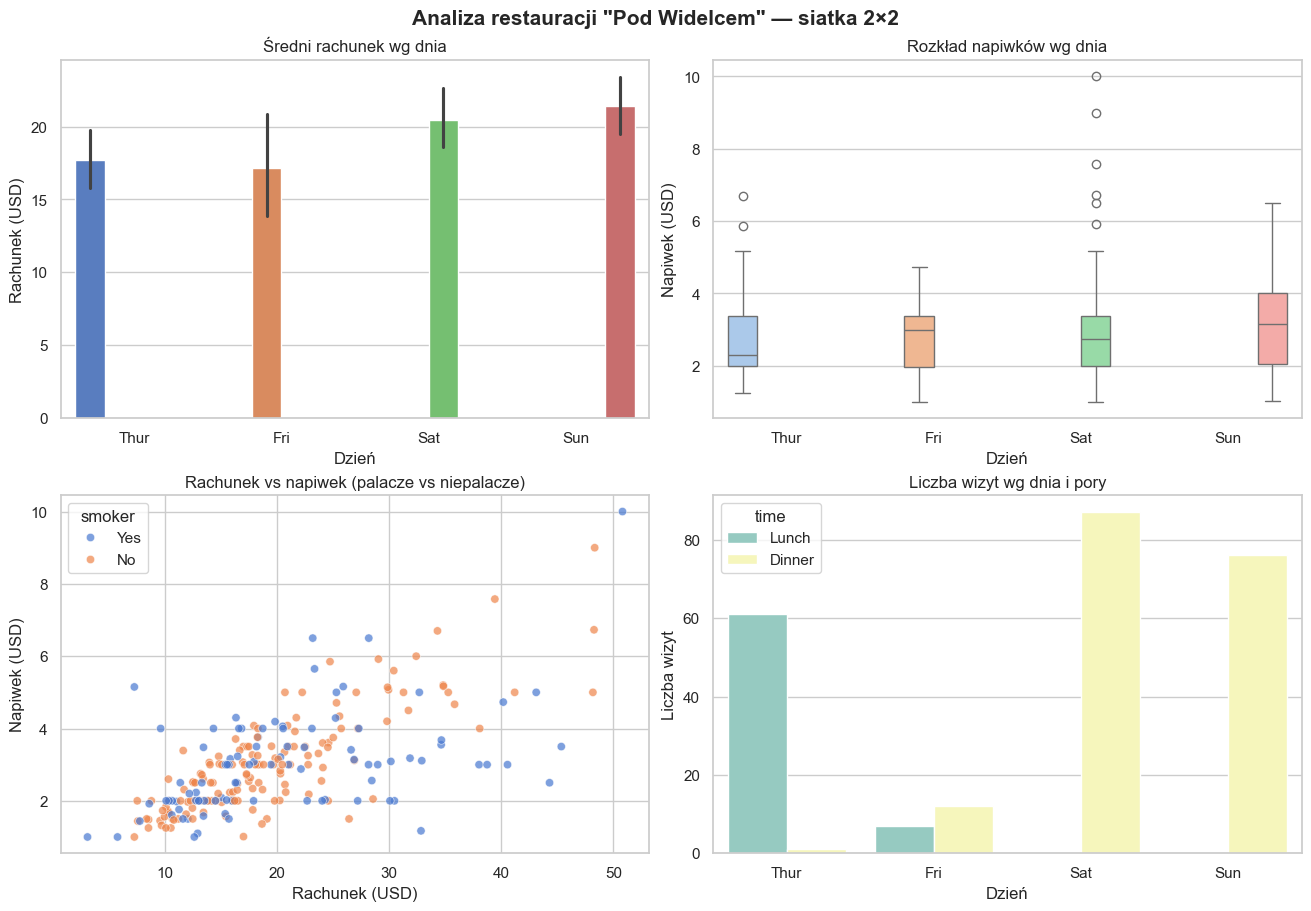

Zapisano: siatka_2x2.png


In [21]:
# Ćw 2.1 Regularna siatka 2×2 Cztery wykresy z datasetu tips na jednej figurze.
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
 ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
 data=tips,
 x='day', # 'day'
 y='tip', # 'tip'
 hue='day', legend=False,
 ax=axes[0, 1],
 palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
 data=tips,
 x='total_bill', # 'total_bill'
 y='tip', # 'tip'
hue='smoker',
 alpha=0.7,
 ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
 data=tips,
 x='day', # 'day'
 hue='time',
 ax=axes[1, 1],
 palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2',
 fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

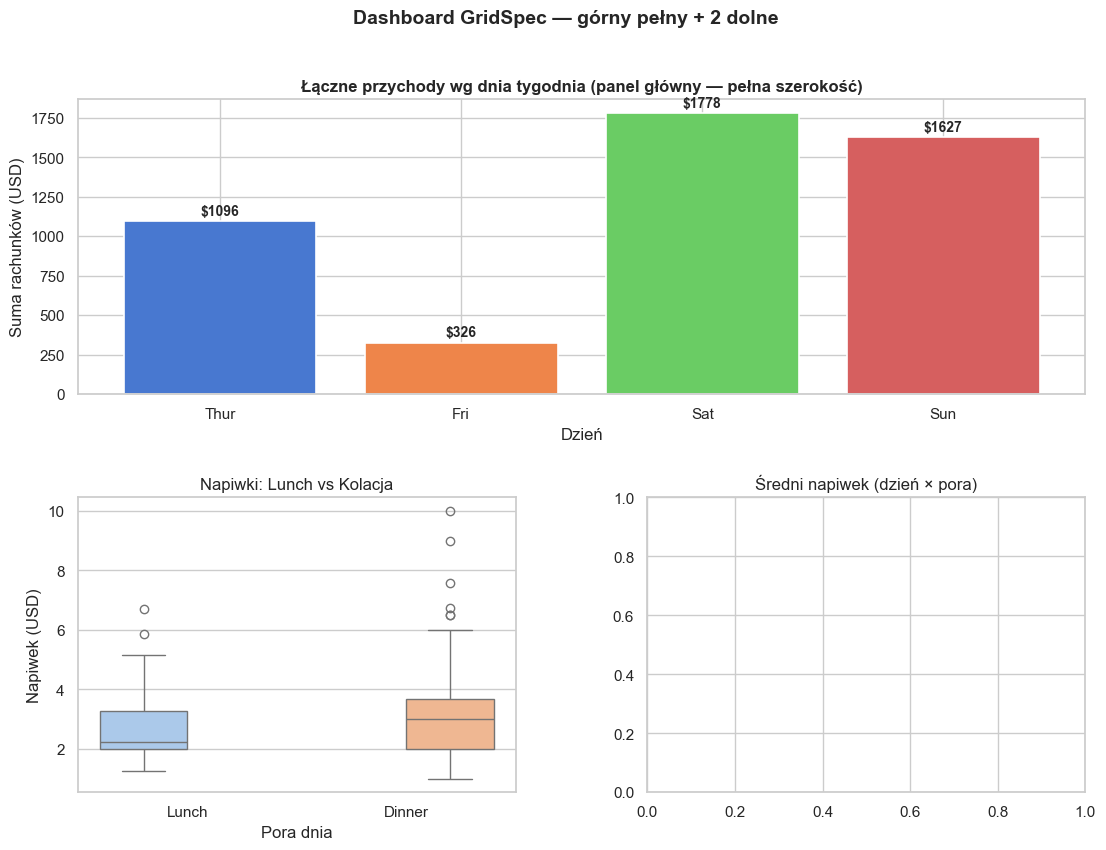

Zapisano: gridspec_dashboard.png


In [22]:
# Ćw 2.2 GridSpec — nieregularny dashboard Stwórz Figure z GridSpec(2, 2) w której górny rząd to jeden panel 
# (pełna szerokość), a dolny rząd ma 2 panele.
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
# Górny — pełna szerokość: barplot suma rachunków per dzień
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
 tips_sum['day'].astype(str),
 tips_sum['total_bill'],
 color=sns.color_palette('muted')[:4],
 edgecolor='white', linewidth=1.2,
)
# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
 ax_top.text(i, val + 20, f'${val:.0f}',
 ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)',
 fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')
# Dolny lewy — boxplot Lunch vs Dinner (uzupełnij)
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
 data=tips,
 x='time', # 'time'
 y='tip', # 'tip'
 hue='time',
 ax=ax_bl,
 palette='pastel',
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')
# Dolny prawy — heatmap pivot (samodzielnie)
# Cel: stwórz pivot_table — wiersze=day, kolumny=time, wartości=mean(tip)
# Zwizualizuj jako heatmap z annot=True, fmt='.2f', cmap='YlOrRd'
ax_br = fig.add_subplot(gs[1, 1])
# Twój kod:
# pivot = tips.pivot_table(...)
# sns.heatmap(...)
ax_br.set_title('Średni napiwek (dzień × pora)')
fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne',
 fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

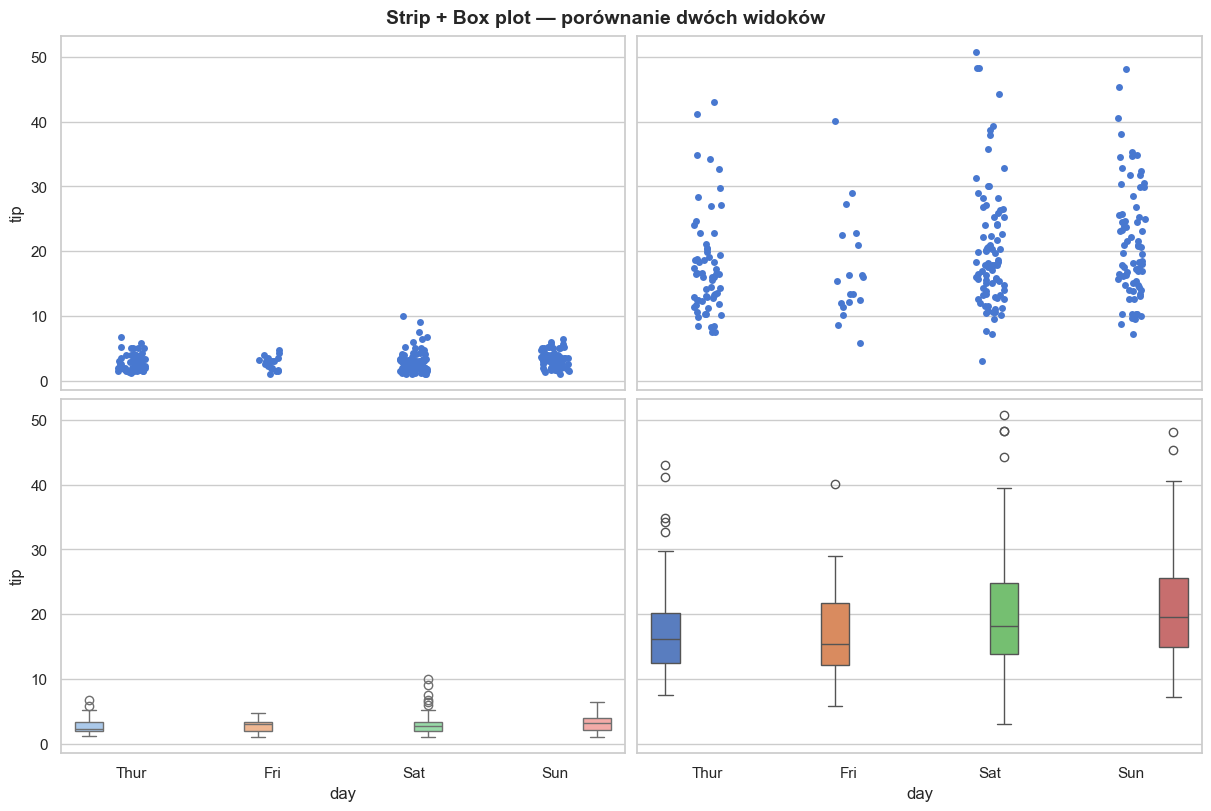

In [23]:
# Ćw 2.3 Shared axes (samodzielnie)
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex='col',
    sharey='row',
    constrained_layout=True
)

# axes[0, 0] — stripplot napiwki
sns.stripplot(
    data=tips,
    x='day',
    y='tip',
    jitter=True,
    ax=axes[0, 0]
)

# axes[1, 0] — boxplot napiwki
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day',
    legend=False,
    palette='pastel',
    ax=axes[1, 0]
)

# axes[0, 1] — stripplot rachunki
sns.stripplot(
    data=tips,
    x='day',
    y='total_bill',
    jitter=True,
    ax=axes[0, 1]
)

# axes[1, 1] — boxplot rachunki
sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='day',
    legend=False,
    palette='muted',
    ax=axes[1, 1]
)

fig.suptitle(
    'Strip + Box plot — porównanie dwóch widoków',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'shared_axes.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

# Ćwiczenie 3 

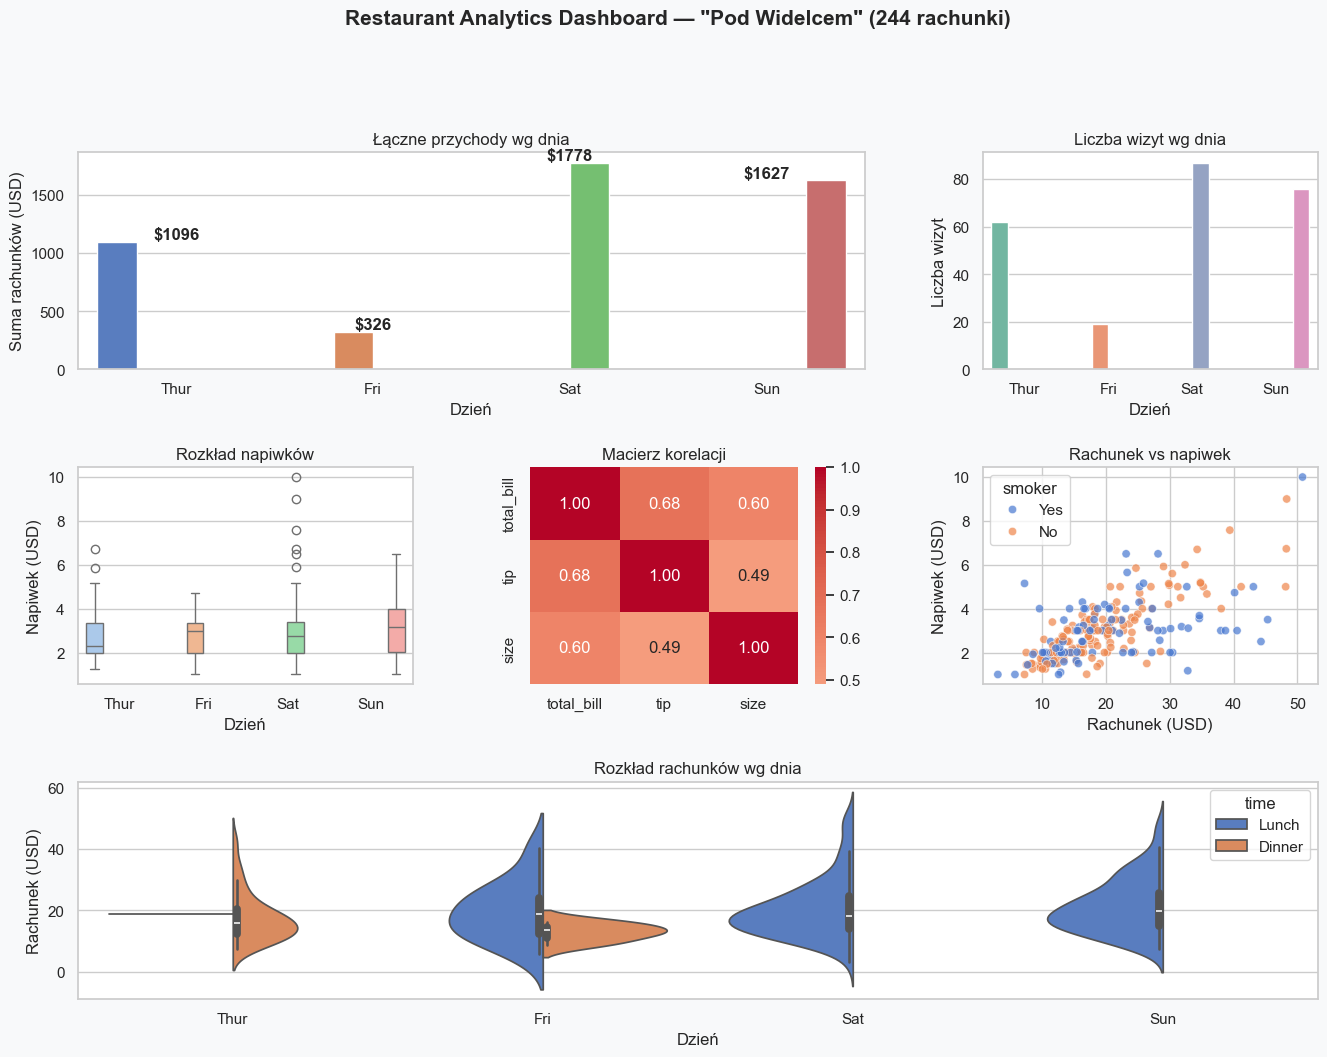

Zapisano: dashboard_pod_widelcem.png


In [25]:
# Ćw 3.2
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# === PANEL 1 — KPI główny ===
ax1 = fig.add_subplot(gs[0, :2])

tips_sum = (
    tips.groupby('day', observed=True)['total_bill']
    .sum()
    .reset_index()
)

sns.barplot(
    data=tips_sum,
    x='day',
    y='total_bill',
    hue='day',
    legend=False,
    palette='muted',
    ax=ax1
)

for i, val in enumerate(tips_sum['total_bill']):
    ax1.text(
        i,
        val + 20,
        f'${val:.0f}',
        ha='center',
        fontweight='bold'
    )

ax1.set_title('Łączne przychody wg dnia')
ax1.set_xlabel('Dzień')
ax1.set_ylabel('Suma rachunków (USD)')


# === PANEL 2 — liczba wizyt ===
ax2 = fig.add_subplot(gs[0, 2])

sns.countplot(
    data=tips,
    x='day',
    hue='day',
    legend=False,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Liczba wizyt wg dnia')
ax2.set_xlabel('Dzień')
ax2.set_ylabel('Liczba wizyt')


# === PANEL 3 — boxplot napiwków ===
ax3 = fig.add_subplot(gs[1, 0])

sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day',
    legend=False,
    palette='pastel',
    ax=ax3
)

ax3.set_title('Rozkład napiwków')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Napiwek (USD)')


# === PANEL 4 — heatmap korelacji ===
ax4 = fig.add_subplot(gs[1, 1])

corr = tips.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax4
)

ax4.set_title('Macierz korelacji')


# === PANEL 5 — scatter ===
ax5 = fig.add_subplot(gs[1, 2])

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    alpha=0.7,
    ax=ax5
)

ax5.set_title('Rachunek vs napiwek')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')


# === PANEL 6 — violinplot ===
ax6 = fig.add_subplot(gs[2, :])

sns.violinplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='time',
    split=True,
    palette='muted',
    ax=ax6
)

ax6.set_title('Rozkład rachunków wg dnia')
ax6.set_xlabel('Dzień')
ax6.set_ylabel('Rachunek (USD)')


fig.suptitle(
    'Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.savefig(
    'dashboard_pod_widelcem.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: dashboard_pod_widelcem.png")

### Wnioski biznesowe

1. Najbardziej dochodowym dniem dla restauracji jest sobota (Sat) — wtedy suma rachunków jest najwyższa.

2. Istnieje wyraźna dodatnia korelacja między wartością rachunku a napiwkiem. Klienci z większymi rachunkami zwykle zostawiają większe napiwki.

3. Palacze i niepalacze zostawiają podobne napiwki, choć wśród palaczy widoczny jest większy rozrzut wartości.

4. Właściciel powinien szczególnie wzmacniać obsługę i promocje weekendowe, ponieważ sobota i niedziela generują największe przychody restauracji.

# Ćwiczenie 4 

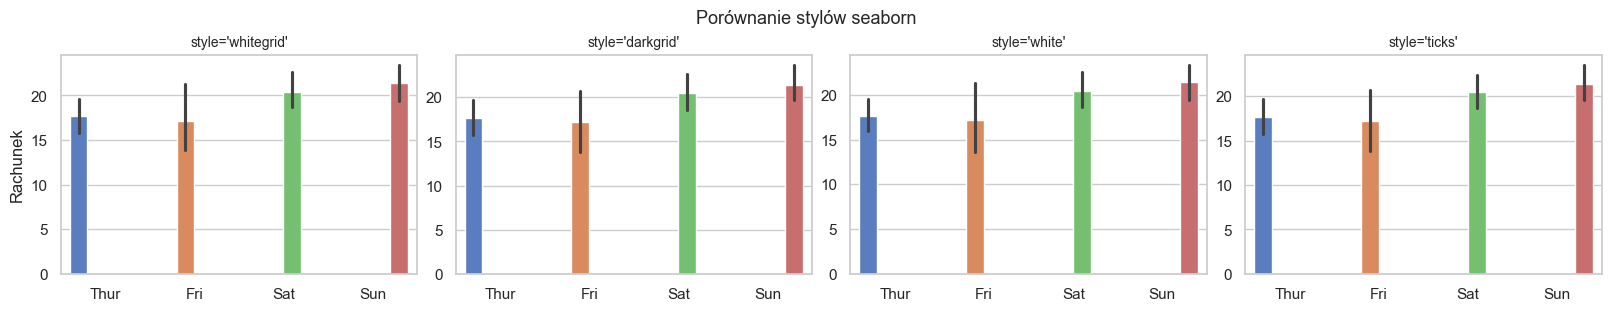

In [27]:
# Ćw 4.1 
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
 with sns.axes_style(style): # context manager — tymczasowo zmień styl
    sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
 ax=ax, palette='muted')
 ax.set_title(f"style='{style}'", fontsize=10)
 ax.set_xlabel('')
 ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()


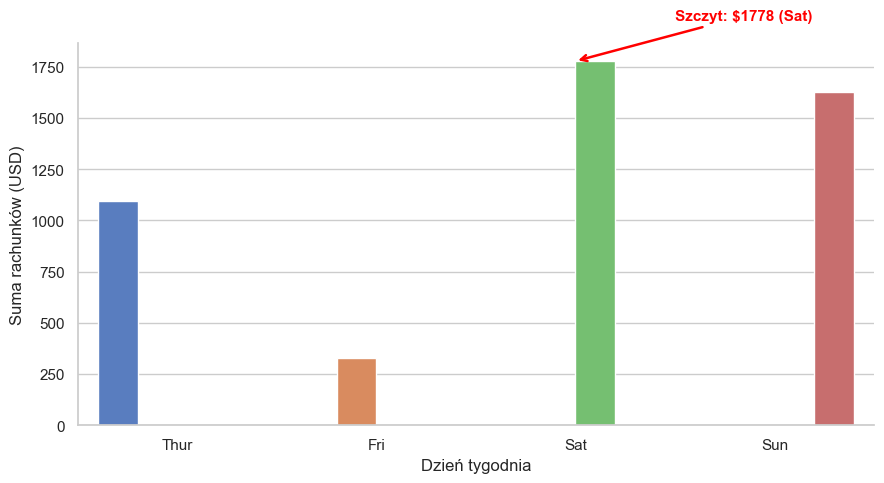

Zapisano: szczyt_przychodow.png


In [30]:
#Ćw 4.2 
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
 ax=ax, palette='muted')
# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']
# Adnotacja ze strzałką
ax.annotate(
 f'Szczyt: ${max_val:.0f} ({max_day})',
 xy=(max_idx, max_val), # punkt na który wskazuje strzałka — (max_idx, max_val)
 xytext=(max_idx + 0.5, max_val + 200), # gdzie tekst — (max_idx + 0.5, max_val + 200)
 arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
 fontsize=11, color='red', fontweight='bold',
)
# Tytuł celowo pominięty — adnotacja 'Szczyt: $...' sama w sobie informuje o czym wykres
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine() # usuwa górną i prawą krawędź osi (minimalistyczny styl)
plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")